## Handling Imbalanced Dataset Using SMOTE

### What is SMOTE?

#### SMOTE stands for Synthetic Minority Oversampling Technique. It is a method used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE generates synthetic instances of the minority class by interpolating between existing minority class instances.

In [1]:
from sklearn.datasets import make_classification

In [2]:
# Create an imbalanced dataset with 1000 samples, 2 features, 1 cluster per class, and class weights to induce imbalance
X, y = make_classification(n_samples=1000, n_features=2, n_clusters_per_class=1,
                            weights=[0.90], random_state=12, n_redundant=0)

In [3]:
import pandas as pd

# Create DataFrames for features and target

df1 = pd.DataFrame(X, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
# Concatenate features and target into a single DataFrame
final_df = pd.concat([df1, df2], axis=1)

In [4]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

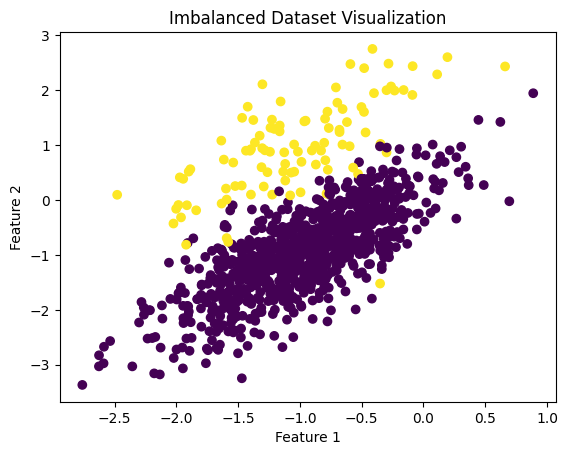

In [5]:
import matplotlib.pyplot as plt

plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Imbalanced Dataset Visualization')
plt.show()

In [7]:
%pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
from imblearn.over_sampling import SMOTE

In [9]:
# Initialize SMOTE oversampler
oversample = SMOTE()

# Apply SMOTE to the dataset
X_resampled, y_resampled = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [10]:
print(X_resampled.shape)  # (1800, 2)
print(y_resampled.shape)  # (1800,)

(1800, 2)
(1800,)


In [11]:
import numpy as np

print(np.sum(y_resampled == 0))  # 900
print(np.sum(y_resampled == 1))  # 900

900
900


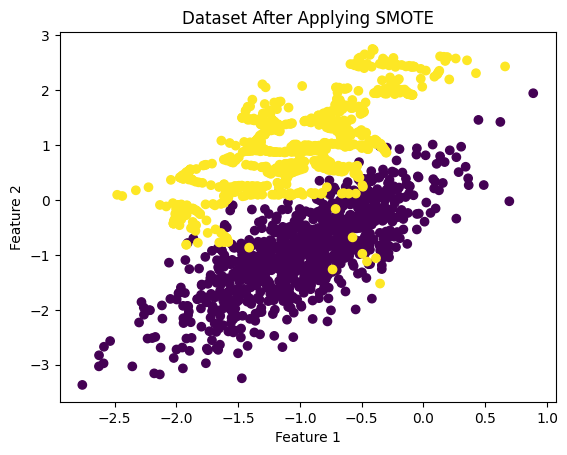

In [12]:
oversampled_df = pd.concat([
    pd.DataFrame(X_resampled, columns=['f1', 'f2']),
    pd.DataFrame(y_resampled, columns=['target'])
], axis=1)

plt.scatter(oversampled_df['f1'], oversampled_df['f2'], c=oversampled_df['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset After Applying SMOTE')
plt.show()